# Register image based on query image
> Image registration

In [ ]:
#| default_exp preprocessing.zero_degree_solder_pin.image_registration

In [ ]:
#| hide
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
#| export
import sys
from pathlib import Path
from threading import Thread
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor
from concurrent.futures import ProcessPoolExecutor
import concurrent.futures


In [ ]:
#| export
CV_TOOLS = Path(r'/home/ai_sintercra/homes/hasan/projects/git_data/cv_tools')
sys.path.append(str(CV_TOOLS))

# %% ../../../nbs/39_preprocessing.zero_degree_solder_pin.ipynb 6
custom_lib_path = Path(r'/home/ai_warstein/homes/goni/custom_libs')
sys.path.append(str(custom_lib_path))
from dotenv import load_dotenv

In [ ]:
#| export
CV_TOOLS = Path(r'/home/ai_sintercra/homes/hasan/projects/git_data/cv_tools')
sys.path.append(str(CV_TOOLS))


In [ ]:
#| export
custom_lib_path = Path(r'/home/ai_warstein/homes/goni/custom_libs')
sys.path.append(str(custom_lib_path))


In [ ]:
#| export
from cv_tools.imports import *
from cv_tools.core import *
from dotenv import load_dotenv
from fastcore.script import *
from fastcore.all import *


In [ ]:
#| export
load_dotenv(dotenv_path=f'/home/ai_sintercra/homes/hasan/projects/git_data/new_test/new_test/.env')

In [ ]:
#| export
class ImageRegistration:
    def __init__(
        self, 
        query_image_path, 
        ):
        store_attr()
        self.query_image = cv2.imread(str(self.query_image_path),0)
    __repr__ = basic_repr()

    def _align_images_ecc(self, test_img_path):
        test_image = cv2.imread(str(test_img_path),0)


        warp_mode = cv2.MOTION_EUCLIDEAN
        crit = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10000, 1e-10)

        # warp matrix
        warp_matrix = np.eye(2, 3, dtype=np.float32)

        # run optimization
        _, warp_matix = cv2.findTransformECC(
            self.query_image, 
            test_image, 
            warp_matrix, 
            warp_mode, crit, None,5)
        # Apply transformation
        h, w = self.query_image.shape
        aligned_image = cv2.warpAffine(
            test_image, 
            warp_matrix, 
            (w, h), 
            flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP)
        
        ssim_score = self._check_alignment(aligned_image)
        if ssim_score < 0.9:
            print(f'SSIM score: {ssim_score}')
            return None

        return aligned_image

    def _check_alignment(self, aligned_image):
        ssim_score = cv2.matchTemplate(
            self.query_image,
            aligned_image, 
            cv2.TM_CCOEFF_NORMED)[0][0]
        print(f'SSIM score: {ssim_score}')
        return ssim_score


In [ ]:
#| export
@patch_to(ImageRegistration)
def _align_images_orb(self, test_img_path):
    test_image = cv2.cvtColor(cv2.imread(str(test_img_path)), cv2.COLOR_BGR2GRAY)

    # Initialize feature detector (ORB is robust and faster than SIFT)
    orb = cv2.ORB_create(nfeatures=2000)
    
    # Find keypoints and descriptors
    kp1, des1 = orb.detectAndCompute(self.query_image, None)
    kp2, des2 = orb.detectAndCompute(test_image, None)
    
    # Create Brute Force Matcher with Hamming distance
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    
    # Match descriptors
    matches = bf.match(des1, des2)
    
    # Sort matches by distance (best matches first)
    matches = sorted(matches, key=lambda x: x.distance)
    
    # Use top matches to find homography
    # Use at least 10 matches or 20% of all matches, whichever is higher
    num_good_matches = max(10, int(len(matches) * 0.2))
    good_matches = matches[:num_good_matches]
    
    # Extract location of good matches
    src_pts = np.float32([kp1[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    
    # Find homography
    H, mask = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC, 5.0)
    
    # Apply homography to align test image
    h, w = self.query_image.shape[:2]
    aligned_image = cv2.warpPerspective(test_image, H, (w, h))
    
    ssim_score = self._check_alignment(aligned_image)
    if ssim_score < 0.9:
        print(f'SSIM score: {ssim_score}')
        return None

    return aligned_image


In [ ]:
from platform import system
idx = 2
if system() == 'Windows':
    query_img_fn = Path(r'C:\Users\goni\workspace\projects\data\easy_end_test\templates\template_image_1b_crop.png')
    test_im_path = Path(r'E:\CurrentTrainingData20240812_trn_val\Incoming_1B_Loetstift\Incoming_1B_Loetstift_unzip\main_im2_cropped_masks\time_11_04_21_val_frGrnd0.9498_epoch_200.h5\failed\missing\images')
else:
    query_img_fn = Path(r'/home/ai_easypid.work/CurrentTrainingData20240812_trn_val/templates/template_image_1b_crop.png')
    test_im_path = Path(r'/home/ai_easypid.work/CurrentTrainingData20240812_trn_val/Incoming_1B_Loetstift/Incoming_1B_Loetstift_unzip/main_im2_cropped_masks/time_11_04_21_val_frGrnd0.9498_epoch_200.h5/failed/missing/images')
test_img = test_im_path.ls()[idx]

In [ ]:
test_img.exists(), query_img_fn.exists()

(True, True)

In [ ]:
img_reg = ImageRegistration(
    query_image_path=query_img_fn,
)
al_img = img_reg._align_images_ecc(test_img)
img_reg._check_alignment(al_img)

SSIM score: 0.9763418436050415


0.97634184

In [ ]:
al_img = img_reg._align_images_orb(test_img)

SSIM score: 0.9523709416389465


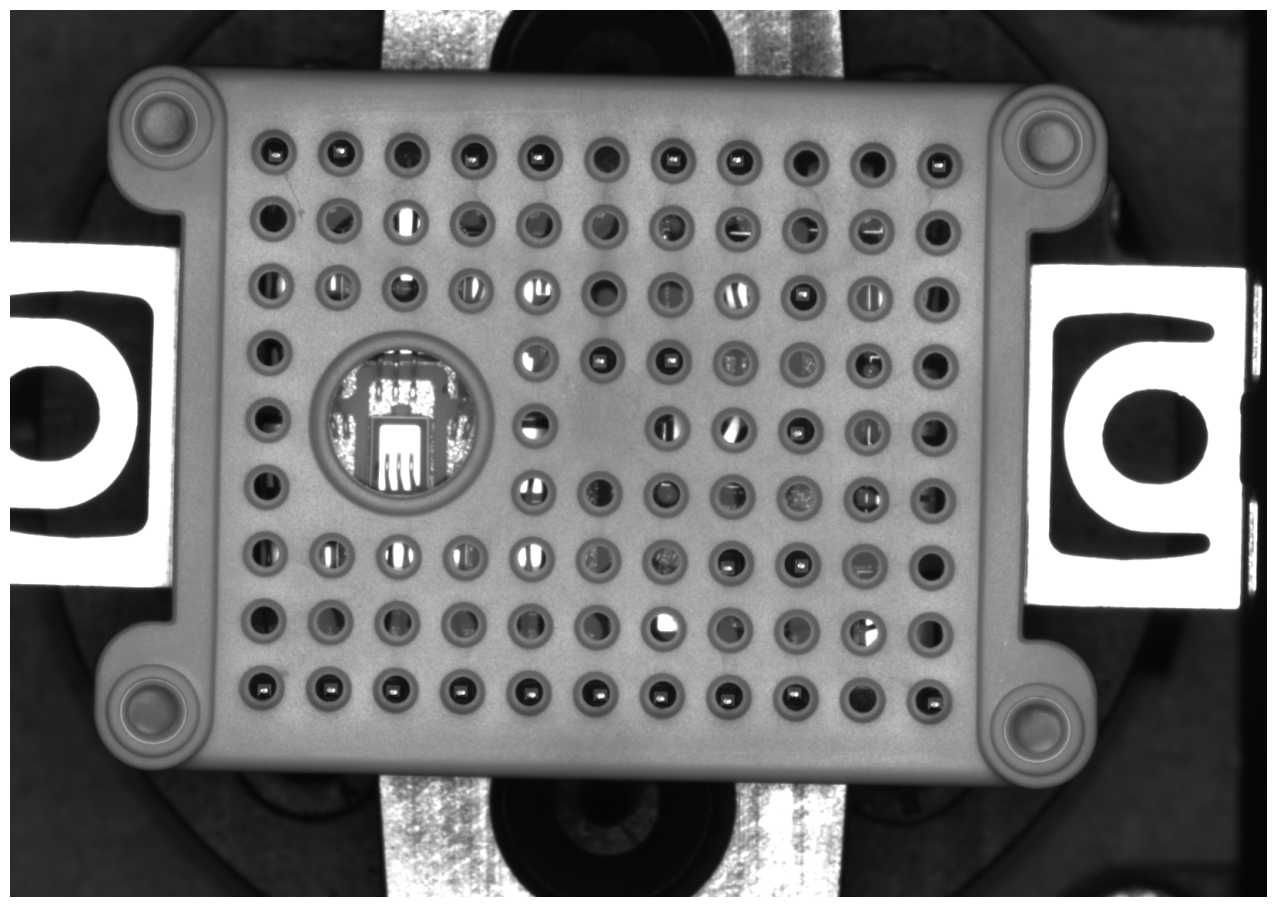

In [ ]:
show_(test_img)

In [ ]:
tst_img_ = cv2.cvtColor(cv2.imread(str(test_img)), cv2.COLOR_BGR2GRAY)
ssim_score = cv2.matchTemplate(img_reg.query_image, tst_img_, cv2.TM_CCOEFF_NORMED)[0][0]
print(f'raw_image SSIM score: {ssim_score}')
al_img = img_reg._align_images_orb(test_img)
ssim_score = cv2.matchTemplate(img_reg.query_image, al_img, cv2.TM_CCOEFF_NORMED)[0][0]
print(f'aligned_image SSIM score: {ssim_score}')

raw_image SSIM score: 0.9196205139160156
SSIM score: 0.9523709416389465
aligned_image SSIM score: 0.9523709416389465


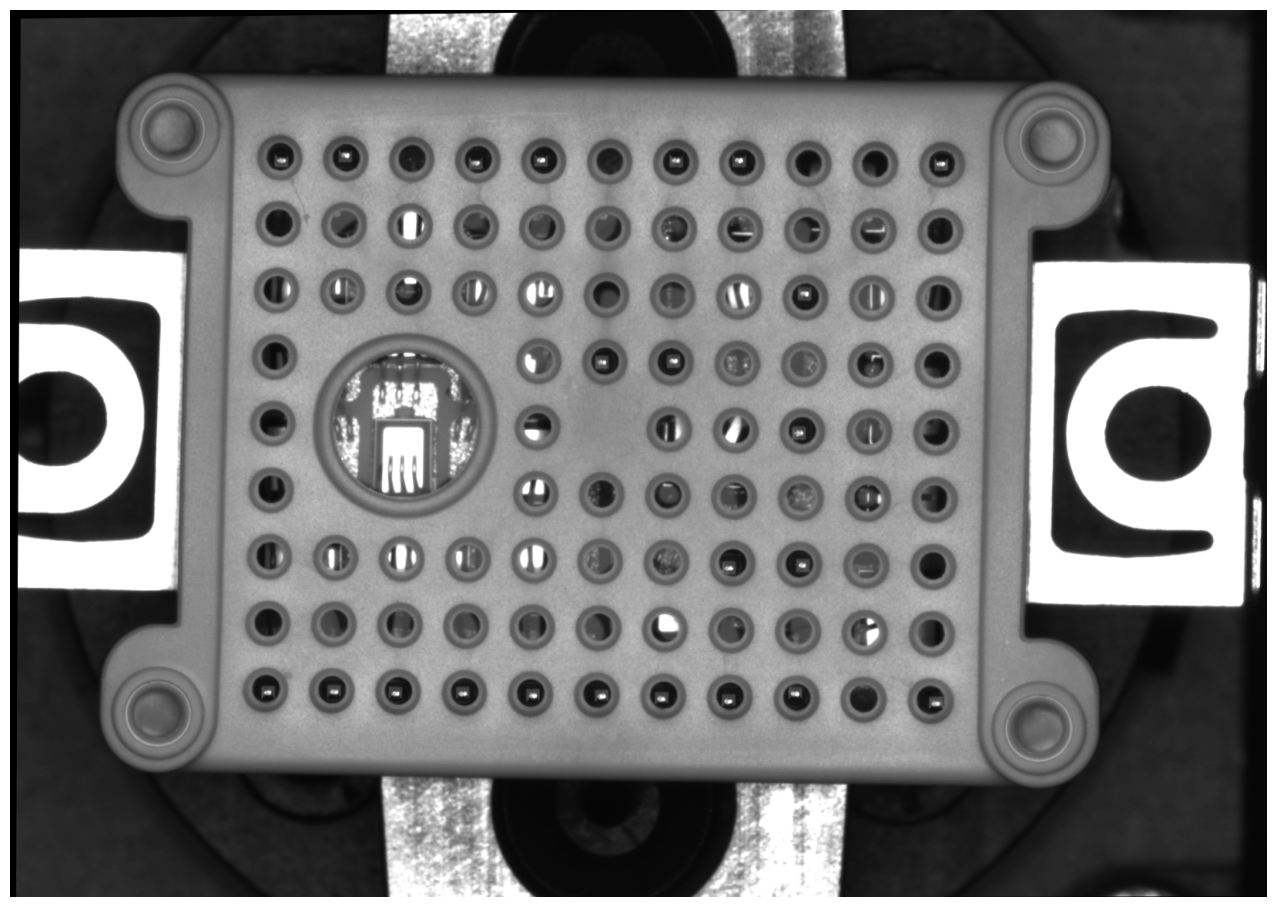

In [ ]:
show_(al_img)

In [ ]:
#| export
CURRETNT_NB='/home/ai_sintercra/homes/hasan/projects/git_data/new_test/nbs'

In [ ]:
test_im_path

Path('E:/CurrentTrainingData20240812_trn_val/Incoming_1B_Loetstift/Incoming_1B_Loetstift_unzip/main_im2_cropped_masks/time_11_04_21_val_frGrnd0.9498_epoch_200.h5/failed/missing/images')

In [ ]:
parallel_image_registration(
    query_image_path=query_img_fn,
    search_folder=test_im_path,
    output_folder=test_im_path / 'aligned',
    non_aligned_folder=test_im_path / 'non_aligned',
    method='ecc',
    similarity_threshold=0.9,
)

Aligning images:   0%|          | 0/3 [00:00<?, ?it/s]

Registration complete:
- Total images processed: 3
- Successfully aligned (similarity ≥ 0.9): 3
- Non-aligned (similarity < 0.9): 0


{'E:\\CurrentTrainingData20240812_trn_val\\Incoming_1B_Loetstift\\Incoming_1B_Loetstift_unzip\\main_im2_cropped_masks\\time_11_04_21_val_frGrnd0.9498_epoch_200.h5\\failed\\missing\\images\\VFV4.9.0.3_2025031710532648_ID_00099046905819403042510_In_17_FRONT_Pass_image2.png': {'similarity': 0.99999934,
  'output_path': 'E:\\CurrentTrainingData20240812_trn_val\\Incoming_1B_Loetstift\\Incoming_1B_Loetstift_unzip\\main_im2_cropped_masks\\time_11_04_21_val_frGrnd0.9498_epoch_200.h5\\failed\\missing\\images\\aligned\\VFV4.9.0.3_2025031710532648_ID_00099046905819403042510_In_17_FRONT_Pass_image2.png'},
 'E:\\CurrentTrainingData20240812_trn_val\\Incoming_1B_Loetstift\\Incoming_1B_Loetstift_unzip\\main_im2_cropped_masks\\time_11_04_21_val_frGrnd0.9498_epoch_200.h5\\failed\\missing\\images\\VFV4.9.0.3_2025031710562409_ID_00119046905819403042510_In_17_FRONT_Pass_image2.png': {'similarity': 0.96845293,
  'output_path': 'E:\\CurrentTrainingData20240812_trn_val\\Incoming_1B_Loetstift\\Incoming_1B_Loet

In [ ]:
#| export

def parallel_image_registration(
    query_image_path, 
    search_folder, 
    output_folder=None,
    non_aligned_folder=None,
    method='ecc',
    similarity_threshold=0.9,
    max_workers=os.cpu_count(),
    file_extensions=('.jpg', '.jpeg', '.png', '.tif', '.tiff'
    )):
    """
    Parallely search images from a folder and apply image registration.
    
    Args:
        query_image_path: Path to the reference image
        search_folder: Folder containing images to be aligned
        output_folder: Folder to save aligned images (default: search_folder/aligned)
        non_aligned_folder: Folder to save images with similarity < threshold (default: search_folder/non_aligned)
        method: Registration method - 'ecc' or 'orb' (default: 'ecc')
        similarity_threshold: Minimum similarity score to consider successful alignment (default: 0.9)
        max_workers: Maximum number of parallel workers (default: number of CPU cores)
        file_extensions: Tuple of file extensions to process
    
    Returns:
        dict: Results with image paths and their similarity scores
    """
    # Setup paths
    search_folder = Path(search_folder)
    if output_folder is None:
        output_folder = search_folder / 'aligned'
    else:
        output_folder = Path(output_folder)
        
    if non_aligned_folder is None:
        non_aligned_folder = search_folder / 'non_aligned'
    else:
        non_aligned_folder = Path(non_aligned_folder)
    
    # Create output directories if they don't exist
    output_folder.mkdir(exist_ok=True, parents=True)
    non_aligned_folder.mkdir(exist_ok=True, parents=True)
    
    # Initialize image registration
    img_reg = ImageRegistration(query_image_path=query_image_path)
    
    # Get all image files
    image_files = [f for f in search_folder.glob('**/*') 
                  if f.is_file() and f.suffix.lower() in file_extensions]
    
    results = {}
    
    def process_image(img_path):
        try:
            # Skip if the file is in output or non_aligned folders
            if output_folder in img_path.parents or non_aligned_folder in img_path.parents:
                return None
            
            # Align image based on method
            if method.lower() == 'ecc':
                aligned_img = img_reg._align_images_ecc(img_path)
            else:
                aligned_img = img_reg._align_images_orb(img_path)
            
            # Calculate similarity score
            similarity = cv2.matchTemplate(img_reg.query_image, aligned_img, cv2.TM_CCOEFF_NORMED)[0][0]
            
            # Determine output path
            rel_path = img_path.relative_to(search_folder)
            if similarity >= similarity_threshold:
                out_path = output_folder / rel_path
            else:
                out_path = non_aligned_folder / rel_path
            
            # Create parent directories if needed
            out_path.parent.mkdir(exist_ok=True, parents=True)
            
            # Save aligned image
            cv2.imwrite(str(out_path), aligned_img)
            
            return (img_path, similarity, out_path)
        except Exception as e:
            print(f"Error processing {img_path}: {e}")
            return None
    
    # Process images in parallel
    with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(process_image, img_path): img_path for img_path in image_files}
        
        # Show progress bar
        for future in tqdm(concurrent.futures.as_completed(futures), total=len(image_files), desc="Aligning images"):
            result = future.result()
            if result:
                img_path, similarity, out_path = result
                results[str(img_path)] = {'similarity': similarity, 'output_path': str(out_path)}
    
    # Summary
    aligned_count = sum(1 for v in results.values() if v['similarity'] >= similarity_threshold)
    non_aligned_count = sum(1 for v in results.values() if v['similarity'] < similarity_threshold)
    
    print(f"Registration complete:")
    print(f"- Total images processed: {len(results)}")
    print(f"- Successfully aligned (similarity ≥ {similarity_threshold}): {aligned_count}")
    print(f"- Non-aligned (similarity < {similarity_threshold}): {non_aligned_count}")
    
    return results


In [ ]:
#| export
@call_parse
def main_(
    query_image_fn:Param("Path to the query image to use as reference")='query_image.png',
    search_folder:Param("Folder containing images to be aligned")='/search_folder',
    output_folder:Param("Folder to save aligned images", default=None)=None,
    non_aligned_folder:Param("Folder to save non-aligned images", default=None)=None,
    method:Param("Registration method to use", default='ecc')='ecc',
    similarity_threshold:Param("Minimum similarity score to consider an image aligned",type=float, default=0.9)=0.9,
    max_workers:Param("Number of parallel workers",type=int, default=os.cpu_count())=30,
    file_extensions:Param("File extensions to process", default=('.jpg', '.jpeg', '.png', '.tif', '.tiff'))='.png'
):
    parallel_image_registration(
        query_image_path=query_image_fn,
        search_folder=search_folder,
        output_folder=output_folder,
        non_aligned_folder=non_aligned_folder,
        method=method,
        similarity_threshold=similarity_threshold,
        max_workers=max_workers,
        file_extensions=file_extensions
    )


In [ ]:
#| hide
import nbdev; nbdev.nbdev_export('44_preprocessing.zero_degree_solder_pin.image_registration.ipynb')

ValueError: '\\\\vihsdv140.infineon.com\\ai_sintercra\\homes\\hasan\\projects\\nbs\\39_preprocessing.zero_degree_solder_pin.ipynb' is not in the subpath of '\\\\vihsdv140.infineon.com\\ai_sintercra\\homes\\hasan\\projects\\git_data\\new_test\\nbs'